In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
from glob import glob
import os
import seaborn as sns

In [ ]:
paths = {
    "MSD-Heart+FIFO":"output/msd_task02+no_agent+icl+no_augment/2026-04-03-19-32-08/msd_Task02_agentFalse_ablation.csv",
    "MSD-Heart+AFS":"output/msd_task02+icl+ppo+skip_penalty+long_horizon+no_augment/2026-04-08-08-07-00/msd_Task02_agentTrue_ablation.csv",
    "Sarcoma+AFS": "output/sarcoma+icl+ppo+long_horizon+no_augment/2026-04-10-19-46-46/sarcoma__agentTrue_ablation.csv",
    "Sarcoma+FIFO": "output/sarcoma+icl+no_agent+long_horizon+no_augment/2026-04-10-19-47-31/sarcoma__agentFalse_ablation.csv",
    # "Sarcoma+FIFO": "output/sarcoma+icl+ppo+long_horizon+no_augment/2026-04-10-19-46-46/sarcoma__agentFalse_ablation.csv",
    "MSD-Colon+FIFO":"output/msd_task10+icl+no_agent+long_horizon+no_augment/2026-04-12-15-52-38/msd_Task10_agentFalse_ablation.csv",
    "MSD-Colon+AFS":"output/msd_task10+icl+ppo+long_horizon+no_augment/2026-04-17-18-39-30/msd_Task10_agentTrue_ablation.csv",
    "MSD-Spleen+AFS":"output/msd_task09+icl+ppo+long_horizon+no_augment/2026-04-11-12-20-13/msd_Task09_agentTrue_ablation.csv",
    "MSD-Spleen+FIFO": "output/msd_task09+icl+no_agent+long_horizon+no_augment/2026-04-11-12-19-00/msd_Task09_agentFalse_ablation.csv",
    "MSD-Prostate+FIFO":"output/msd_task05+no_agent+long_horizon+no_augment/2026-04-13-18-04-27/msd_Task05_agentFalse_ablation.csv",
    "MSD-Prostate+AFS":"output/msd_task05+ppo+long_horizon+no_augment/2026-04-13-14-13-19/msd_Task05_agentTrue_ablation.csv",
}

In [128]:
dfs = {}

for l, p in paths.items():
    print(l)
    df = pd.read_csv(p, index_col=0)
    dfs[l] = df

MSD-Heart+FIFO
MSD-Heart+AFS
Sarcoma+AFS
Sarcoma+FIFO
MSD-Colon+FIFO
MSD-Colon+AFS
MSD-Spleen+AFS
MSD-Spleen+FIFO
MSD-Prostate+FIFO
MSD-Prostate+AFS


In [129]:
# display(dfs["MSD-Heart+AFS"][dfs["MSD-Heart+AFS"]["id"] == "la_007.nii.gz_1_58"])

In [130]:
for l, df in dfs.items():
    df["vol_id"] = df["id"].str.split("_").str[1].str.split(".").str[0].astype(np.int64)
    df["obj_id"] = df["id"].str.split("_").str[2].astype(np.int64)
    df["frame_id"] = df["id"].str.split("_").str[3].astype(np.int64)
    dfs[l] = df.set_index(["vol_id", "obj_id", "frame_id"])
    # dfs[l] = df.sort_values(["vol_id", "obj_id", "frame_id"])

In [131]:
for label, df in dfs.items():
    if "FIFO" in label:
        drop_delta = []
        for d, f in zip(df['delta'], df['drop_frame']):
            dices = eval(d)
            if f == -1:
                v = 0
            else:
                deltas = []
                for i, dice in dices.items():
                    if i == f:
                        continue
                    deltas.append(dices[f] - dice) # actual choice - other choices => higher means better
                
                v = np.mean(deltas)
                
            drop_delta.append(v * 100)

        df['drop_delta'] = pd.Series(drop_delta, index=df.index)
    else:
        drop_delta = []
        for frame_id, (d, f) in zip(df['id'], zip(df['delta'], df['drop_frame'])):
            if f == -1:
                v = 0
            else:
                dices = eval(d)
                deltas = []
                for i, dice in dices.items():
                    if i == f:
                        continue
                    deltas.append(dices[f] - dice)  # actual choice - other choices => higher means better  

                if deltas:
                    v = np.mean(deltas)
                else:
                    v = 0
                
            drop_delta.append(v * 100)

        df['drop_delta'] = pd.Series(drop_delta, index=df.index)

In [138]:
join_dfs = {}
mean_delta = {}
for dataset in np.unique([k.split("+")[0] for k in dfs.keys()]):
    rl_df = dfs[dataset+"+AFS"]
    fifo_df = dfs[dataset+"+FIFO"]
    join_df = rl_df.join(fifo_df, on=["vol_id", "obj_id", "frame_id"], lsuffix="_rl", rsuffix="_fifo")
    join_df['dice_diff'] = (join_df['dice_rl'] - join_df['dice_fifo']) * 100
    join_df = join_df[join_df["drop_frame_fifo"] != -1]
    join_df = join_df[join_df['dice_diff'] > 1.0]
    # join_df = join_df[(join_df['dice_diff'] > join_df['dice_diff'].quantile(0))]
    
    # display(join_df)
    # print(join_df.loc[pd.MultiIndex.from_tuples([(30,1,65)], names=["vol_id","obj_id","frame_id"])]['delta_rl'].values[0])
    
    join_dfs[dataset] = join_df
    mean_delta[dataset+"+FIFO"] = join_df["drop_delta_fifo"]
    mean_delta[dataset+"+AFS"] = join_df["drop_delta_rl"]
    
# display(dfs["MSD-Heart+AFS"][dfs["MSD-Heart+AFS"]["id"] == "la_007.nii.gz_1_58"])

In [161]:
display(eval(dfs["Sarcoma+FIFO"][dfs["Sarcoma+FIFO"]["id"] == "STS_050_2_46"]["delta"].values[0]))

{45: 0.0004985188134014606,
 39: 0.28279075026512146,
 40: 0.18054963648319244,
 41: 0.2734737694263458,
 42: 0.2313327044248581,
 43: 0.2825333774089813,
 44: 0.1020253524184227}

In [145]:
display_cols = [
        "dice_diff",
        # "dice_rl",
        # "dice_fifo",
        "id_rl",
        "id_fifo",
        "delta_rl",
        "delta_fifo",
        # "drop_frame_rl",
        # "drop_frame_fifo"
]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(join_dfs["Sarcoma"].sort_values('dice_diff', ascending=False)[display_cols])

dice_diff         id_rl       id_fifo  \
vol_id obj_id frame_id                                          
44     1      23        27.625108  STS_044_1_23  STS_044_1_23   
              22        25.899404  STS_044_1_22  STS_044_1_22   
50     2      46        21.514499  STS_050_2_46  STS_050_2_46   
44     1      26        21.214154  STS_044_1_26  STS_044_1_26   
              25        17.803419  STS_044_1_25  STS_044_1_25   
              24        16.997802  STS_044_1_24  STS_044_1_24   
14     2      28        15.563464  STS_014_2_28  STS_014_2_28   
20     1      13        15.154749  STS_020_1_13  STS_020_1_13   
       2      83        13.759211  STS_020_2_83  STS_020_2_83   
5      1      43        13.275564  STS_005_1_43  STS_005_1_43   
20     1      14        13.187742  STS_020_1_14  STS_020_1_14   
       2      87        11.945751  STS_020_2_87  STS_020_2_87   
44     1      19        11.928010  STS_044_1_19  STS_044_1_19   
26     1      24        11.752206  STS_026_1_24  STS_026_1_24   
20     1      17        11.490965  STS_020_1_17  STS_020_1_17   
44     1      21        11.390829  STS_044_1_21  STS_044_1_21   
              20        10.732782  STS_044_1_20  STS_044_1_20   
45     1      32        10.659552  STS_045_1_32  STS_045_1_32   
20     1      9         10.620570   STS_020_1_9   STS_020_1_9   
45     1      31        10.467196  STS_045_1_31  STS_045_1_31   
44     1      36        10.434955  STS_044_1_36  STS_044_1_36   
20     1      15        10.278332  STS_020_1_15  STS_020_1_15   
44     1      18        10.023797  STS_044_1_18  STS_044_1_18   
14     1      40         9.977284  STS_014_1_40  STS_014_1_40   
20     1      11         9.756851  STS_020_1_11  STS_020_1_11   
              20         9.732270  STS_020_1_20  STS_020_1_20   
              21         9.707987  STS_020_1_21  STS_020_1_21   
              10         9.428376  STS_020_1_10  STS_020_1_10   
              12         9.363210  STS_020_1_12  STS_020_1_12   
              8          9.287518   STS_020_1_8   STS_020_1_8   
45     1      55         9.264809  STS_045_1_55  STS_045_1_55   
20     1      22         9.210044  STS_020_1_22  STS_020_1_22   
              16         9.192491  STS_020_1_16  STS_020_1_16   
45     1      18         8.357930  STS_045_1_18  STS_045_1_18   
34     2      17         8.335501  STS_034_2_17  STS_034_2_17   
20     1      19         8.185399  STS_020_1_19  STS_020_1_19   
26     1      27         8.016682  STS_026_1_27  STS_026_1_27   
14     2      81         7.917976  STS_014_2_81  STS_014_2_81   
34     2      10         7.846594  STS_034_2_10  STS_034_2_10   
50     2      44         7.731825  STS_050_2_44  STS_050_2_44   
20     1      18         7.719219  STS_020_1_18  STS_020_1_18   
14     1      42         7.605472  STS_014_1_42  STS_014_1_42   
44     1      28         7.509452  STS_044_1_28  STS_044_1_28   
20     2      81         7.508951  STS_020_2_81  STS_020_2_81   
45     1      56         7.449108  STS_045_1_56  STS_045_1_56   
20     1      7          7.415366   STS_020_1_7   STS_020_1_7   
       2      80         7.409310  STS_020_2_80  STS_020_2_80   
45     1      30         7.121032  STS_045_1_30  STS_045_1_30   
14     2      12         6.770378  STS_014_2_12  STS_014_2_12   
20     1      23         6.735837  STS_020_1_23  STS_020_1_23   
45     1      33         6.611639  STS_045_1_33  STS_045_1_33   
              25         6.242532  STS_045_1_25  STS_045_1_25   
              29         6.183428  STS_045_1_29  STS_045_1_29   
26     1      25         6.044537  STS_026_1_25  STS_026_1_25   
45     1      28         6.025034  STS_045_1_28  STS_045_1_28   
20     2      58         5.914670  STS_020_2_58  STS_020_2_58   
14     2      79         5.885422  STS_014_2_79  STS_014_2_79   
20     1      24         5.629015  STS_020_1_24  STS_020_1_24   
14     2      10         5.470672  STS_014_2_10  STS_014_2_10   
45     1      20         5.446929  STS_045_1_20  STS_045_1_

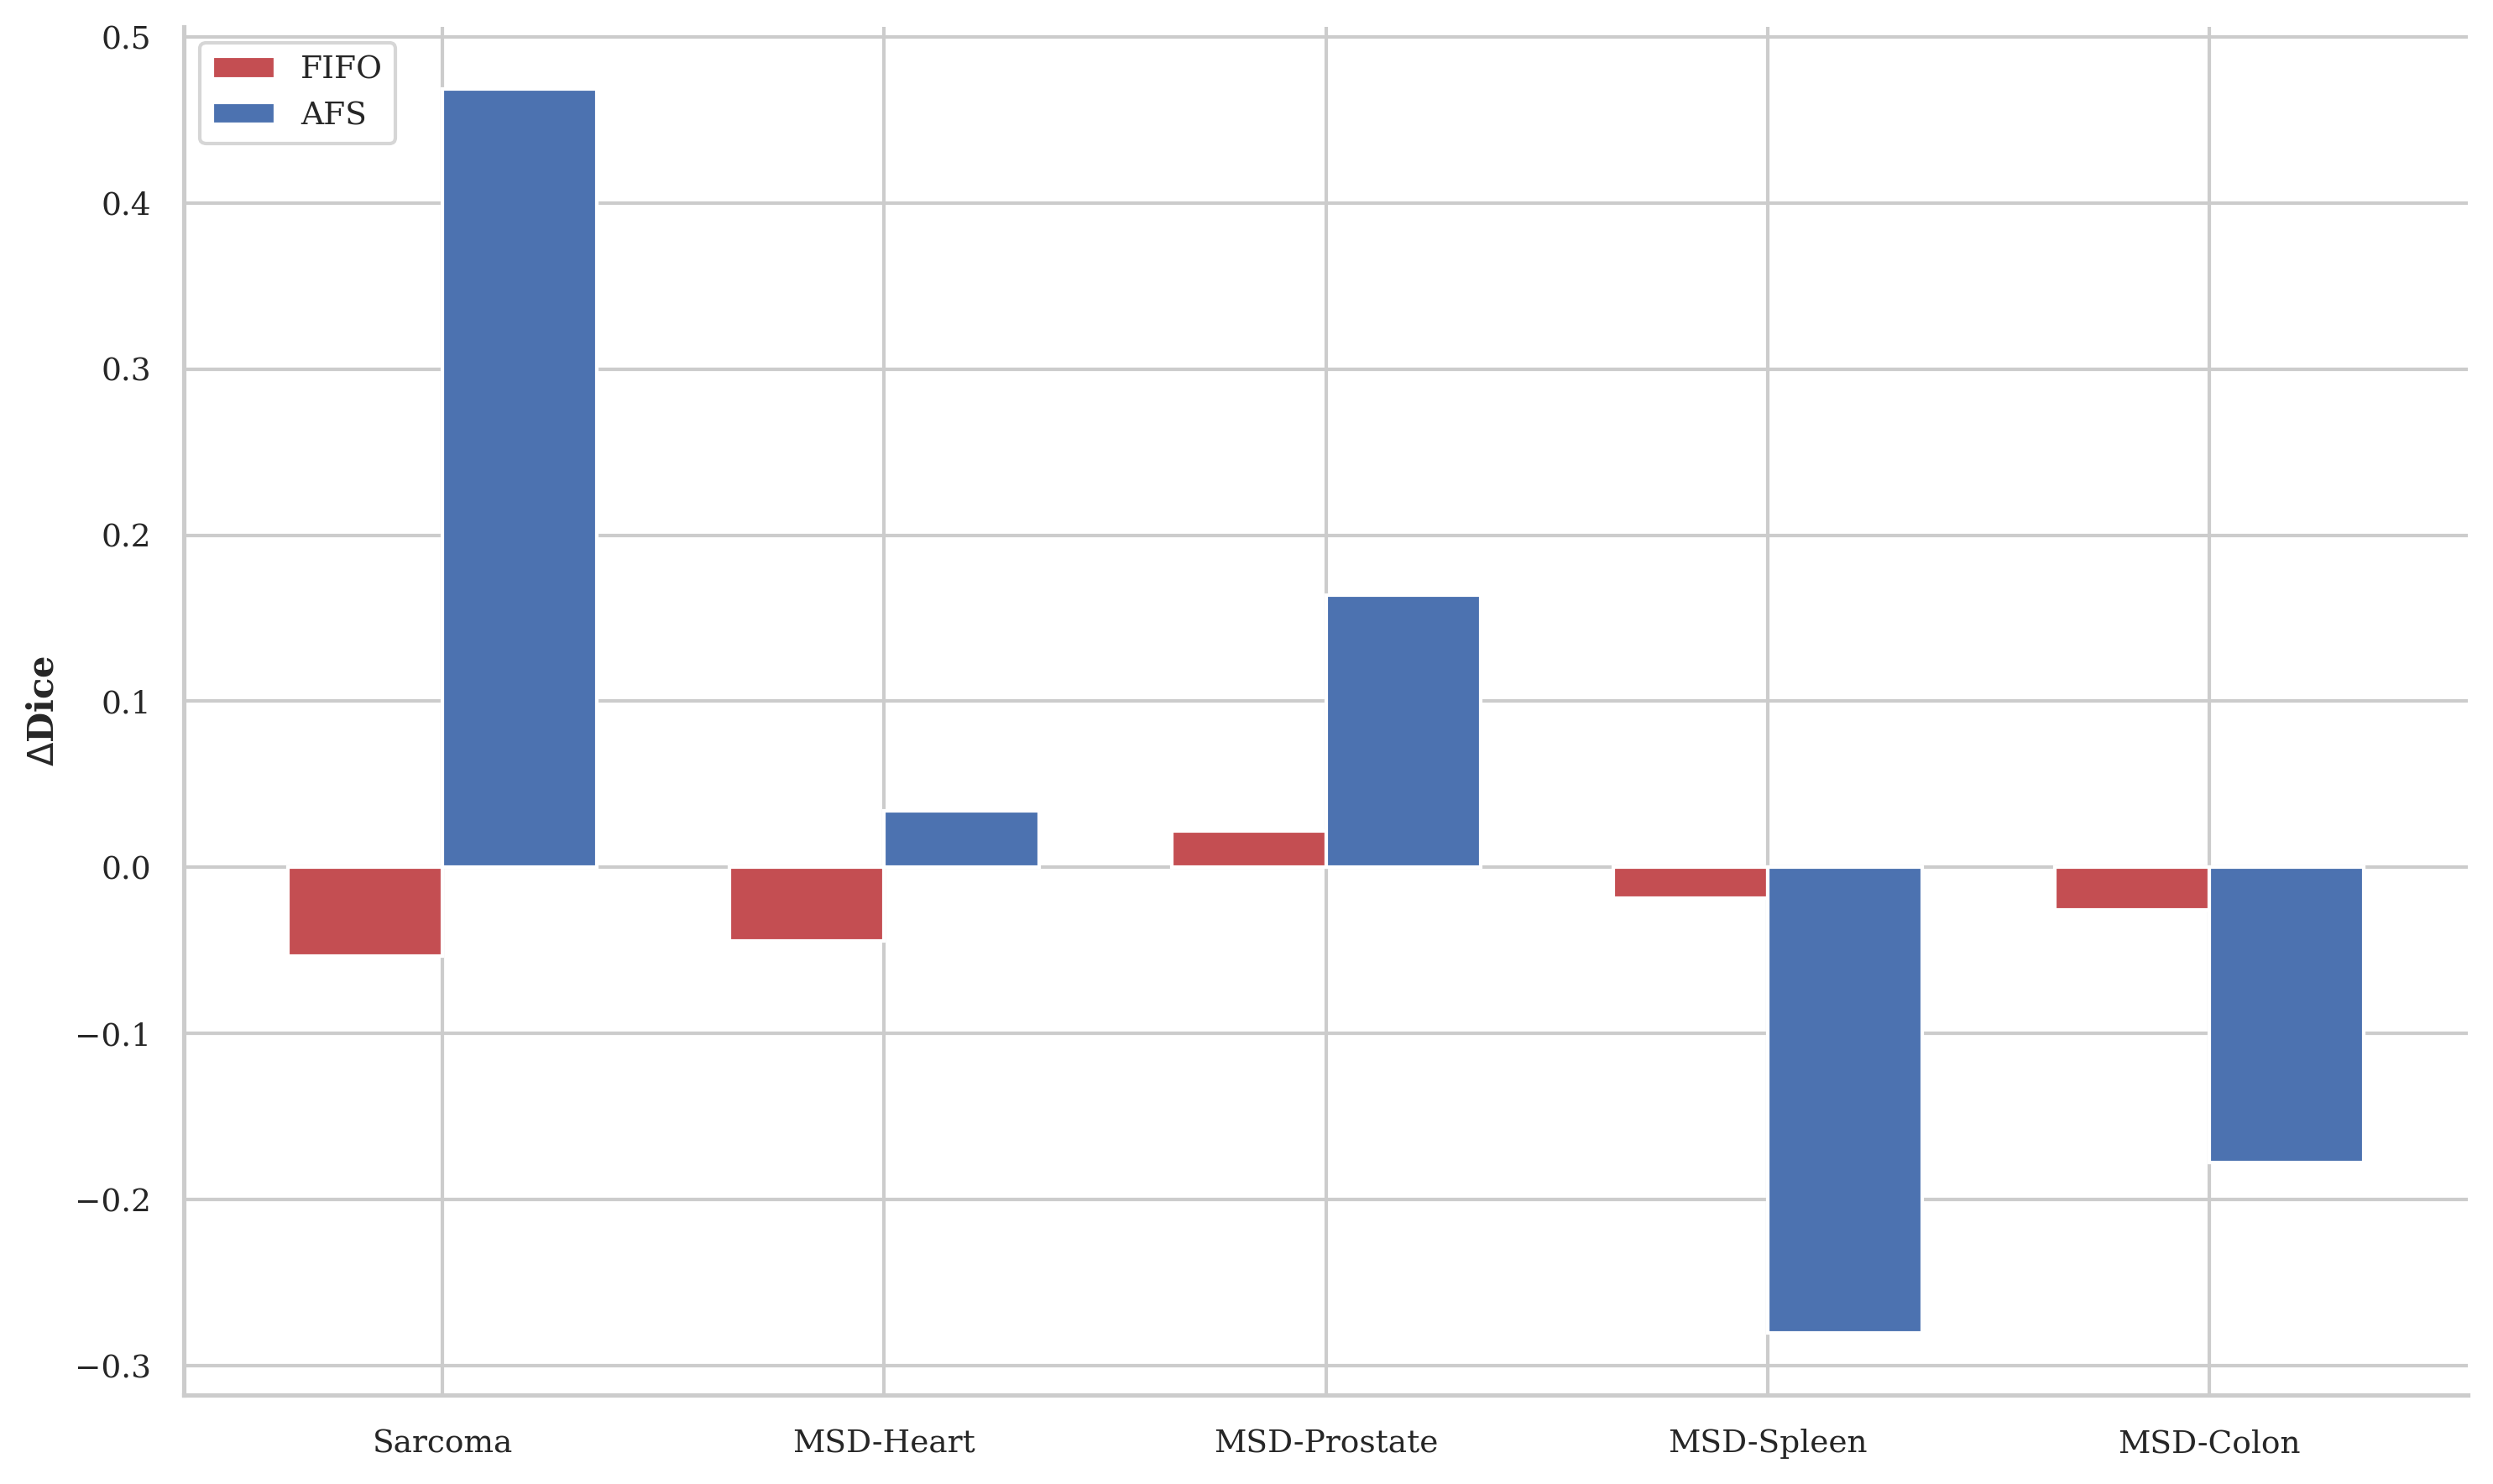

In [140]:
# Set publication-quality style
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
colors = ["#4C72B0", "#C44E52"]
sns.set_palette(sns.color_palette(colors))
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

# Example data structure
datasets = ['Sarcoma', 'MSD-Heart', 'MSD-Prostate', 'MSD-Spleen', 'MSD-Colon']
# fifo_vals = [v.median() for k, v in mean_delta.items() if "FIFO" in k]
# afs_vals = [v.median() for k, v in mean_delta.items() if "AFS" in k]

fifo_vals = [mean_delta[d + "+FIFO"].median() for d in datasets]
afs_vals = [mean_delta[d + "+AFS"].median() for d in datasets]


# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = range(len(datasets))

ax.bar([i - width/2 for i in x], fifo_vals, width, label='FIFO', color='r')
ax.bar([i + width/2 for i in x], afs_vals, width, label='AFS', color='b')
ax.set_ylabel(r'$\Delta$Dice') # LaTeX formatting
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend(frameon=True, loc='upper left')
sns.despine() # Removes unnecessary top/right borders
plt.tight_layout()
# plt.savefig("output/quantitative.pdf")

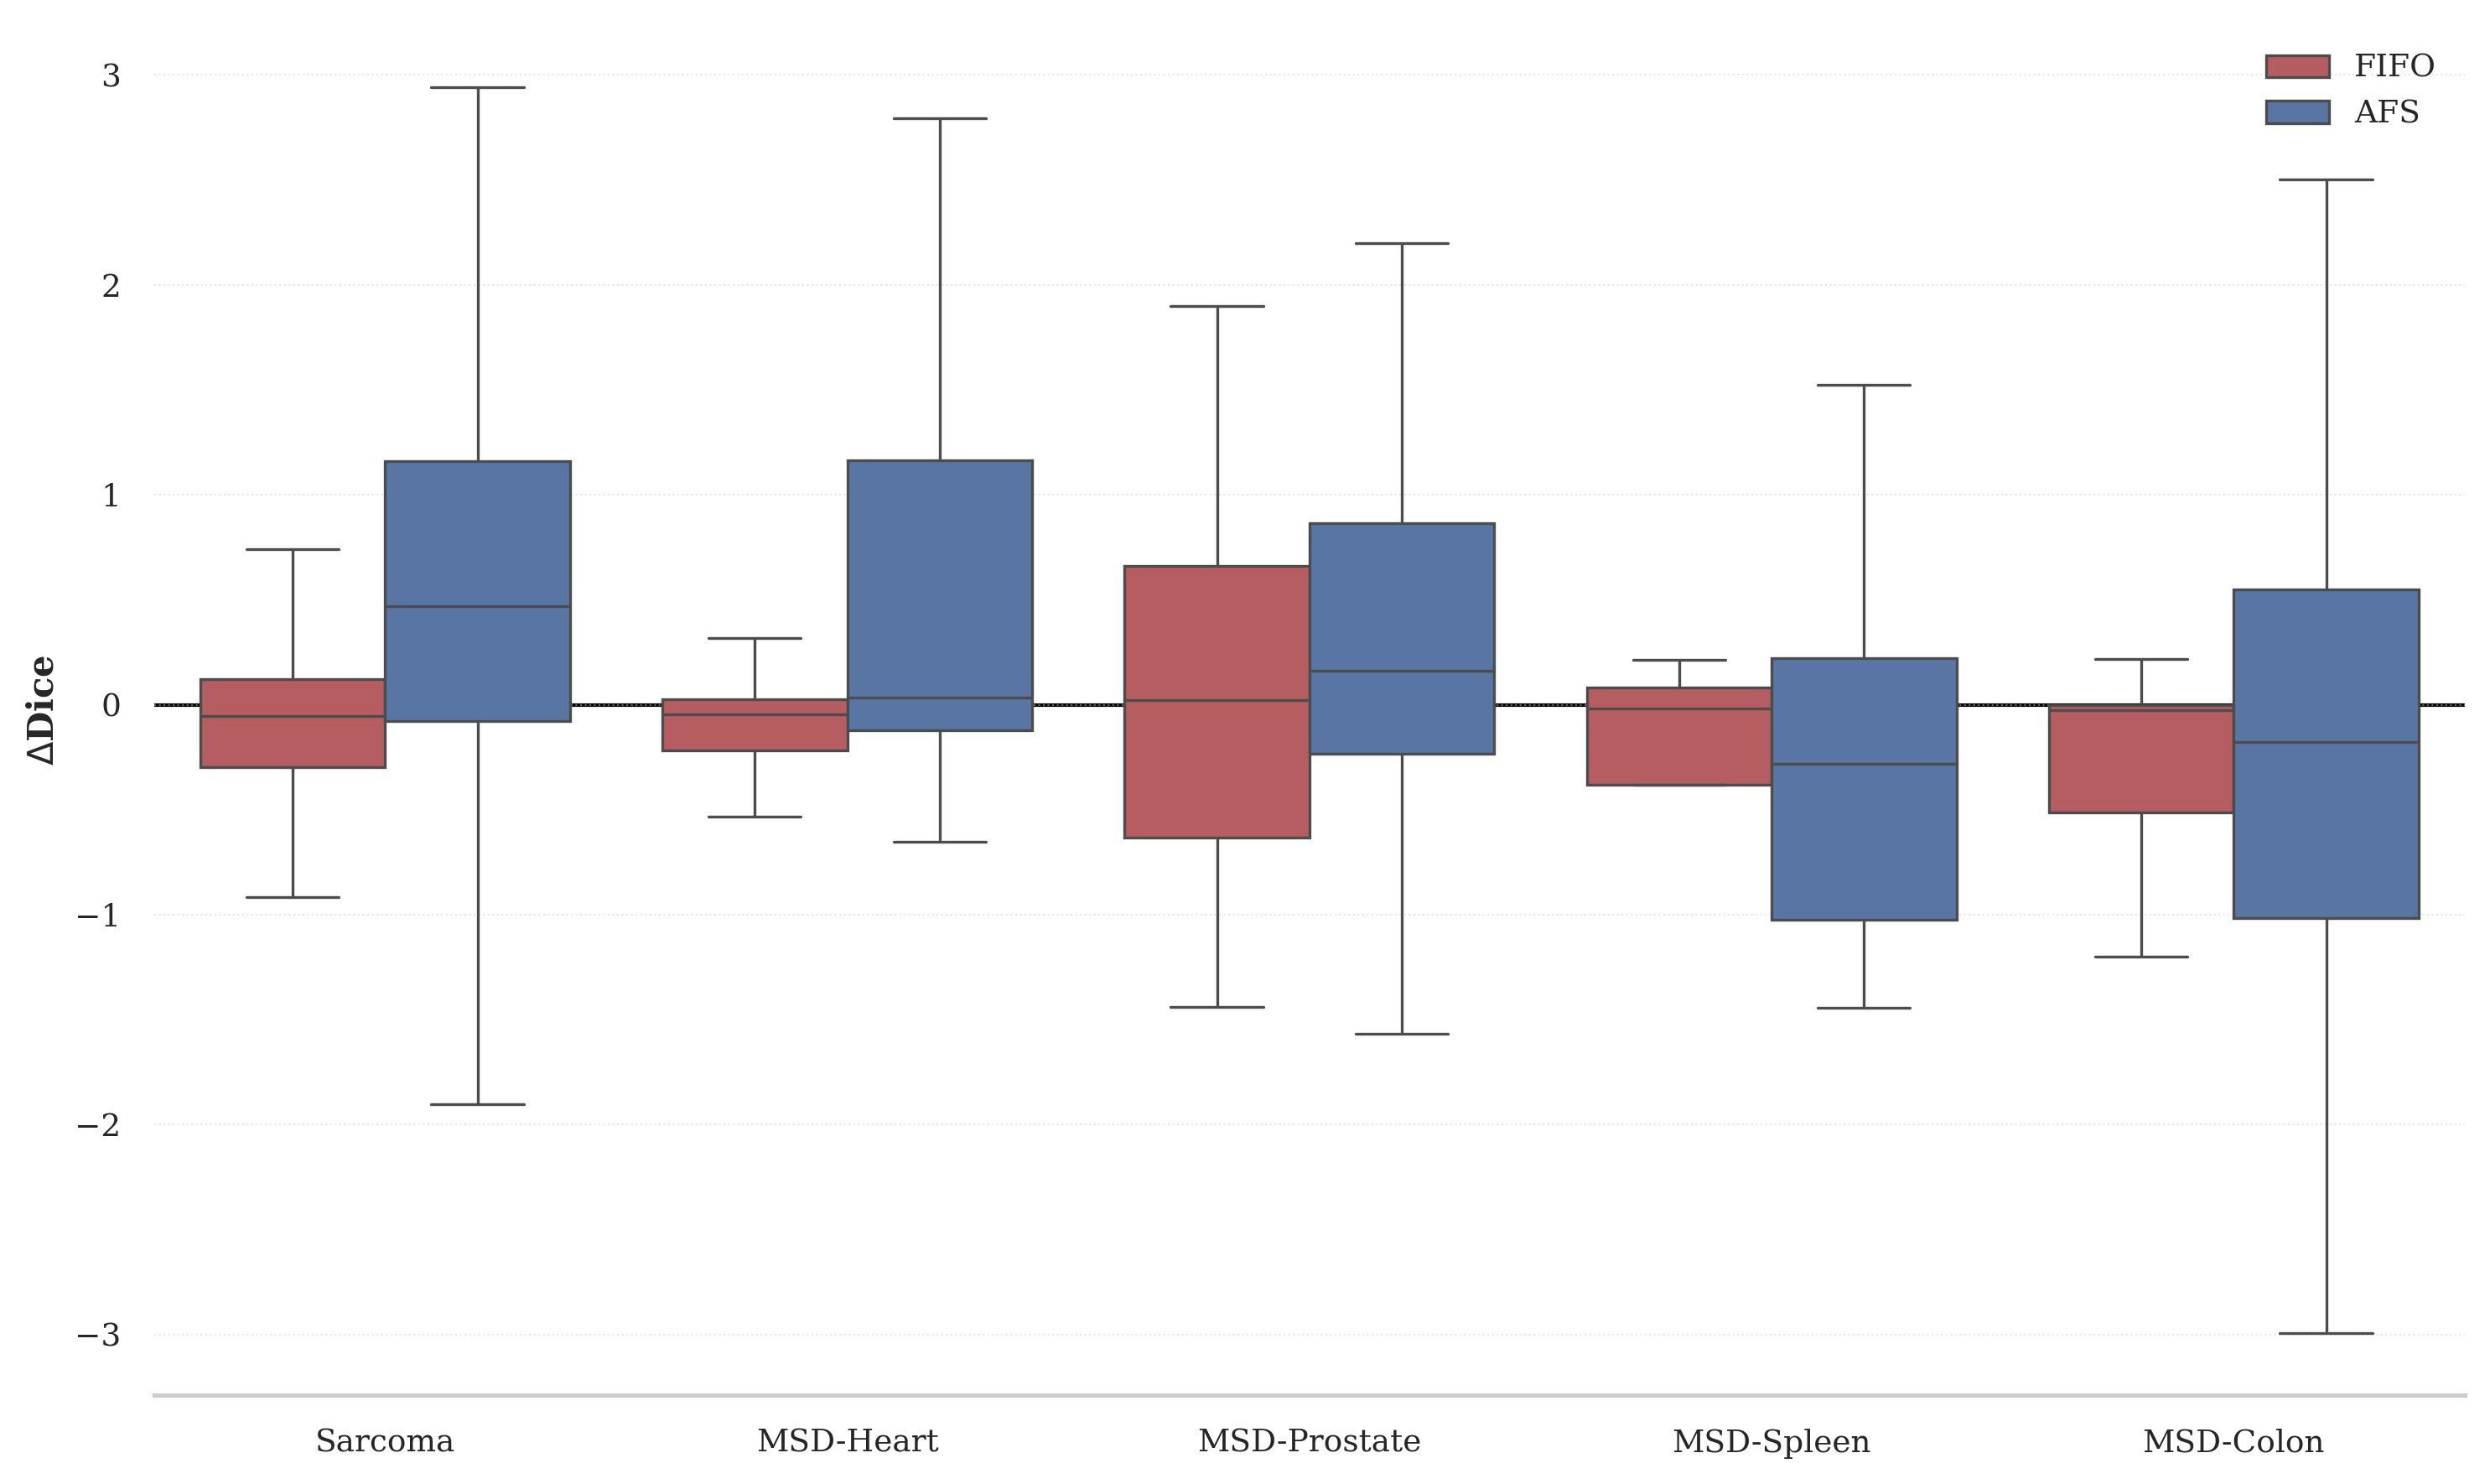

In [141]:
# Set publication-quality style
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
colors = ["#C44E52", "#4C72B0"]
sns.set_palette(sns.color_palette(colors))
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

# 1. Setup synthetic data (simulating distributions around your previous means)
np.random.seed(42)
datasets = ['Sarcoma', 'MSD-Heart', 'MSD-Prostate', 'MSD-Spleen', 'MSD-Colon']

data = []
# Means from your previous chart
fifo_means = [0.85, 2.9, 2.1, 1.45]
afs_means = [-0.1, 1.35, 0.3, 1.38]

for ds in datasets:
    # Generating distribution data
    data.extend([{'Dataset': ds, 'Method': 'FIFO', 'DeltaDice': v} for v in mean_delta[ds+"+FIFO"]])
    data.extend([{'Dataset': ds, 'Method': 'AFS', 'DeltaDice': v} for v in mean_delta[ds+"+AFS"]])

df = pd.DataFrame(data)

# 3. Create the Boxplot
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Dataset',
    y='DeltaDice',
    hue='Method',
    palette=colors,
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3},
    showfliers=False, # Show outliers
    linewidth=0.8,
    ax=ax
)

# Professional tweaks
ax.axhline(0, color='black', linestyle='-', linewidth=1, zorder=0)
ax.set_ylabel(r'$\Delta$Dice')
ax.set_xlabel('') # Often dataset names on x-axis are self-explanatory
sns.despine(left=True) # Clean look
ax.grid(axis='y', linestyle=':', alpha=0.5, linewidth=0.5)
ax.set_axisbelow(True) # Ensure grid is behind the boxes
plt.legend(frameon=False, loc="best")
plt.tight_layout()

# Save as vector for final paper
# plt.savefig('output/quantitative-box.pdf', bbox_inches='tight')
# plt.show()

/tmp/ipykernel_2320586/3609055917.py:50: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


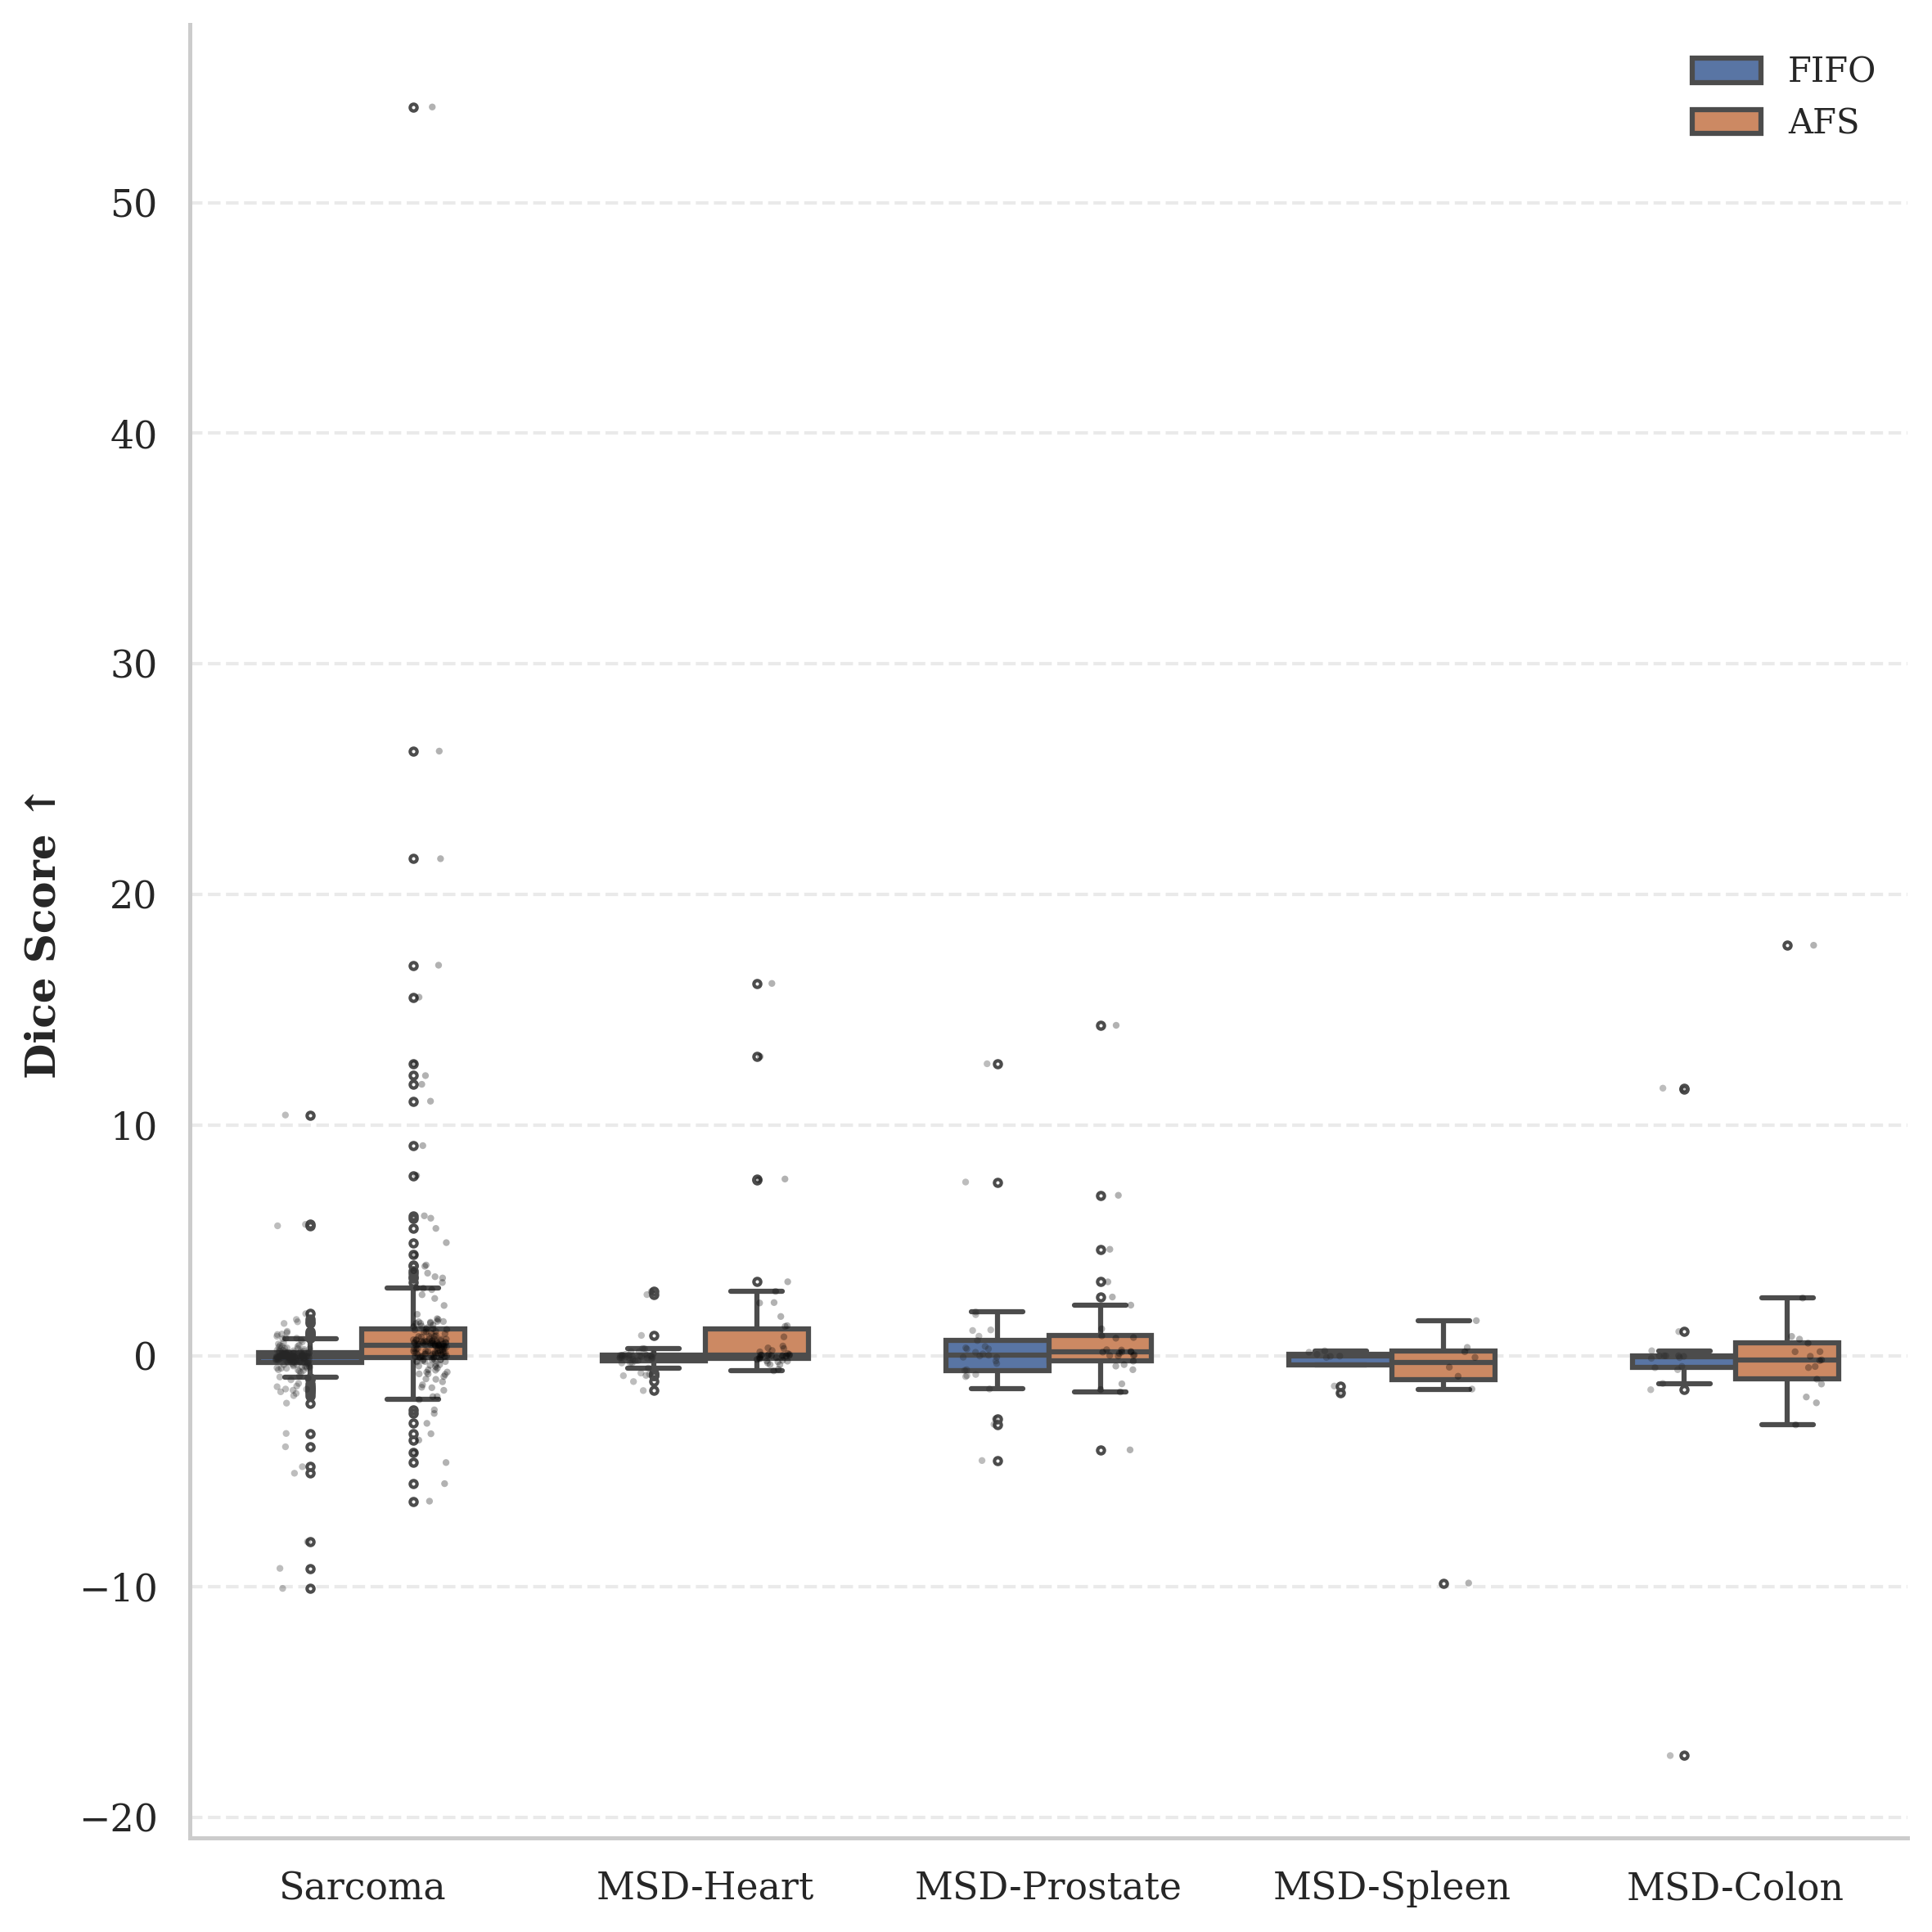

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---- GLOBAL STYLE ----
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,  # Editable text in Illustrator
    "ps.fonttype": 42,
})

# ---- Example Data Structure ----
# Replace with your real data
datasets = ['Sarcoma', 'MSD-Heart', 'MSD-Prostate', 'MSD-Spleen', 'MSD-Colon']
methods = ["FIFO", "AFS"]

data = []
for ds in datasets:
    # Generating distribution data
    data.extend([{'Dataset': ds, 'Method': 'FIFO', 'DeltaDice': v} for v in mean_delta[ds+"+FIFO"]])
    data.extend([{'Dataset': ds, 'Method': 'AFS', 'DeltaDice': v} for v in mean_delta[ds+"+AFS"]])

df = pd.DataFrame(data, columns=["Dataset", "Method", "DeltaDice"])

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 8))

palette = {
    "FIFO": "#4C72B0",
    "AFS": "#DD8452"
}

sns.boxplot(
    data=df,
    x="Dataset",
    y="DeltaDice",
    hue="Method",
    palette=palette,
    width=0.6,
    linewidth=1.5,
    fliersize=2,
    ax=ax
)

sns.stripplot(
    data=df,
    x="Dataset",
    y="DeltaDice",
    hue="Method",
    dodge=True,
    color="black",
    size=2,
    alpha=0.3,
    ax=ax
)

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], frameon=False, fontsize=10)

# Improve axis
ax.set_ylabel("Dice Score ↑", fontsize=12, weight="bold")
ax.set_xlabel("")
# ax.set_ylim(0.6, 0.95)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("quantitative_box_eccv.pdf", dpi=600, bbox_inches="tight")
plt.show()